In [1]:
pip install tensorflow matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize
x_train, x_test = x_train/255.0, x_test/255.0

def LeNet():
    model = models.Sequential([
        layers.Conv2D(6, (5,5), activation='relu', input_shape=(32,32,3)),
        layers.AveragePooling2D(pool_size=(2,2)),  # ✅ FIX

        layers.Conv2D(16, (5,5), activation='relu'),
        layers.AveragePooling2D(pool_size=(2,2)),  # ✅ FIX

        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model
def AlexNet():
    model = models.Sequential([
        layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.MaxPooling2D(),
        layers.Conv2D(192, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(384, (3,3), activation='relu', padding='same'),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model
def VGG():
    model = models.Sequential([
        layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model
from tensorflow.keras import Input, Model

def ResNet():
    inputs = Input(shape=(32,32,3))

    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(inputs)
    skip = x

    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.Add()([x, skip])  # Skip connection

    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    return Model(inputs, outputs)
def train_and_test(model):
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    model.fit(x_train, y_train, epochs=3, verbose=1)

    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    return acc
models_dict = {
    "LeNet": LeNet(),
    "AlexNet": AlexNet(),
    "VGG": VGG(),
    "ResNet": ResNet()
}

results = {}

for name, model in models_dict.items():
    print("\nTraining:", name)
    acc = train_and_test(model)
    results[name] = acc
    print(name, "Accuracy:", acc)

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training: LeNet
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3350 - loss: 1.8159
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.4860 - loss: 1.4319
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.5262 - loss: 1.3256
LeNet Accuracy: 0.5364000201225281

Training: AlexNet
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 264s 168ms/step - accuracy: 0.3680 - loss: 1.7028
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 318s 165ms/step - accuracy: 0.6543 - loss: 0.9817
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 283s 179ms/step - accuracy: 0.7404 - loss: 0.7346
AlexNet Accuracy: 0.7376999855041504

Training: VGG
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 213s 135ms/step - accuracy: 0.4046 - loss: 1.6256
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 253s 130ms/step - accuracy: 0.6705 - loss: 0.9367
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 272s 136ms/step - accuracy: 0.7532 - loss: 0.6999
VGG Accuracy: 0.7285000085830688

Training: ResNet
Epoch 1/3
1563/15

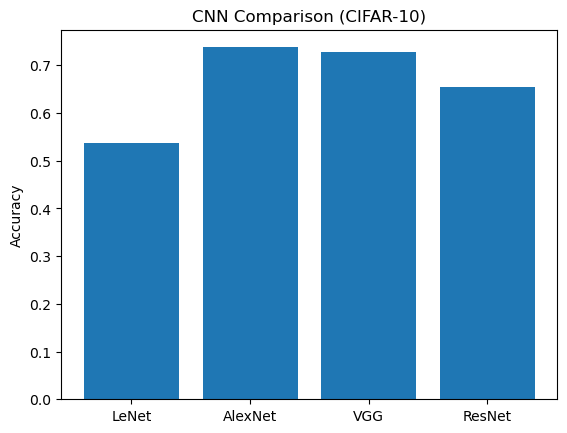

In [4]:
plt.bar(results.keys(), results.values())
plt.title("CNN Comparison (CIFAR-10)")
plt.ylabel("Accuracy")
plt.show()